# Exploratory Data Analysis (EDA) Report – Marketing Campaign Analytics
## 1. Introduction
This report presents an exploratory data analysis (EDA) of the marketing campaign dataset using Python. The primary objective of this analysis is to examine customer demographics, purchasing behavior, and campaign response patterns in order to uncover actionable insights that support retail analytics, customer segmentation, and data-driven marketing decision-making.

## 2. General Data Overview
### 2.1 Dataset Preview and Libraries Loading
The required Python libraries for data analysis and visualization were imported prior to conducting the exploratory analysis. The first few rows of the dataset were then displayed using `df.head()` to inspect the dataset structure, understand the available variables, and verify that the dataset was loaded successfully.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from scipy import stats
from scipy.stats import chi2_contingency
import sqlite3
import re

# Read the csv file and store it as a DataFrame named df
df = pd.read_csv('marketing_campaign clean.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,7734,1993,Graduation,Single,79244,0,0,19-12-2012,58,471,...,10,7,1,0,0,1,1,0,0,1
1,4369,1957,Master,Single,65487,0,0,10/1/2014,48,240,...,5,6,2,0,0,0,0,0,0,0
2,433,1958,Master,Single,61331,1,1,10/3/2013,42,534,...,1,6,8,0,0,0,0,0,0,0
3,7660,1973,PhD,Single,35860,1,1,19-05-2014,37,15,...,1,2,5,1,0,0,0,0,0,1
4,92,1988,Graduation,Single,34176,1,0,12/5/2014,12,5,...,0,4,6,0,0,0,0,0,0,0


### 2.2 Dataset Dimensions
The dimensions of the dataset were examined using the dataset shape to determine the total number of observations (rows) and variables (columns), providing an overview of the dataset size and analytical scope.

In [3]:
print("Dimensions (rows, columns):",df.shape)

Dimensions (rows, columns): (2240, 28)


### 2.3 Data Types Inspection and Missing Values Analysis
The data types of all variables were reviewed using `df.dtypes` to ensure that each column was stored in an appropriate format for analysis. Additionally, missing values were identified using `df.isnull().sum()` to assess data completeness and detect any potential data quality issues prior to performing further analysis.

In [4]:
df.dtypes

ID                      int64
Year_Birth              int64
Education              object
Marital_Status         object
Income                  int64
Kidhome                 int64
Teenhome                int64
Dt_Customer            object
Recency                 int64
MntWines                int64
MntFruits               int64
MntMeatProducts         int64
MntFishProducts         int64
MntSweetProducts        int64
MntGoldProds            int64
Total_spending          int64
NumDealsPurchases       int64
NumWebPurchases         int64
NumCatalogPurchases     int64
NumStorePurchases       int64
NumWebVisitsMonth       int64
AcceptedCmp3            int64
AcceptedCmp4            int64
AcceptedCmp5            int64
AcceptedCmp1            int64
AcceptedCmp2            int64
Complain                int64
Response                int64
dtype: object

In [5]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
Total_spending         0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

## 3. Descriptive Statistics
### 3.1 Summary Statistics
Summary statistics were computed to understand the central tendency and dispersion of the dataset. Key measures such as mean, median, minimum, maximum, and standard deviation were calculated for all numerical variables.

- **Option A**: The describe() function was used to generate an overall statistical summary of the dataset, providing a quick overview of all numerical features.
- **Option B**: Median values were additionally calculated separately to complement the describe() output, ensuring a more robust understanding of the data distribution, especially in the presence of potential outliers.

These two approaches together provide a comprehensive view of the dataset’s distribution and variability.

In [6]:
#option A
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,51473.545982,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107
std,3246.662198,11.984069,21909.882797,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,34686.250000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51025.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68275.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
#option B
summary = df.describe().T
summary["median"] = df.median(numeric_only=True)

summary = summary[["mean", "median", "min", "max", "std"]]
print(summary)

                             mean   median     min       max           std
ID                    5592.159821   5458.5     0.0   11191.0   3246.662198
Year_Birth            1968.805804   1970.0  1893.0    1996.0     11.984069
Income               51473.545982  51025.5  1730.0  162397.0  21909.882797
Kidhome                  0.444196      0.0     0.0       2.0      0.538398
Teenhome                 0.506250      0.0     0.0       2.0      0.544538
Recency                 49.109375     49.0     0.0      99.0     28.962453
MntWines               303.935714    173.5     0.0    1493.0    336.597393
MntFruits               26.302232      8.0     0.0     199.0     39.773434
MntMeatProducts        166.950000     67.0     0.0    1725.0    225.715373
MntFishProducts         37.525446     12.0     0.0     259.0     54.628979
MntSweetProducts        27.062946      8.0     0.0     263.0     41.280498
MntGoldProds            44.021875     24.0     0.0     362.0     52.167439
Total_spending         60

### 3.2 Initial Distribution Analysis
To understand the distribution patterns of key variables, histograms were generated for **Income** and **Year of Birth**.

These visualizations helped in:

- Identifying the **shape of the distribution** (normal, skewed, etc.)
- Observing the **spread and concentration** of values
- Detecting any initial signs of **anomalies or irregular distributions**

Overall, the histograms provided an initial understanding of how the data is distributed across key numerical features.

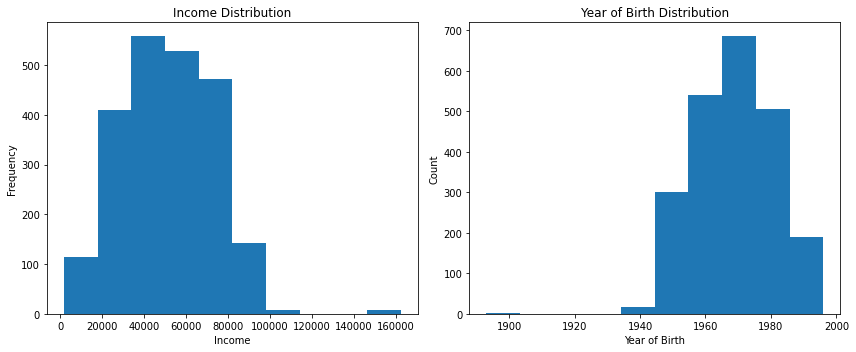

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Income histogram
axes[0].hist(df["Income"], bins=10)
axes[0].set_title("Income Distribution")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Frequency")

# Year_Birth histogram
axes[1].hist(df["Year_Birth"], bins=10)
axes[1].set_title("Year of Birth Distribution")
axes[1].set_xlabel("Year of Birth")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 3.3 Initial Outlier Detection
To detect unusual or extreme values, boxplots were created for **Income** and **Recency**.

These plots were used to:

- Identify **outliers outside the interquartile range (IQR)**
- Visualize the **data spread and central clustering**
- Highlight potential data quality issues or extreme customer behaviors

The boxplots indicated whether further data cleaning or transformation may be required before deeper analysis.

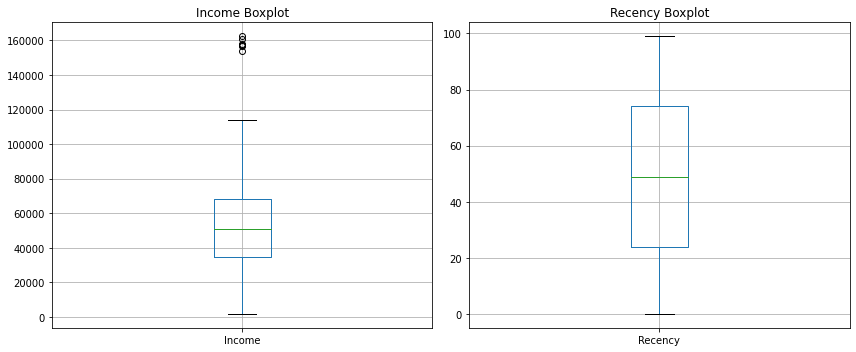

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Income boxplot
df.boxplot(column="Income", ax=axes[0])
axes[0].set_title("Income Boxplot")

# Recency boxplot
df.boxplot(column="Recency", ax=axes[1])
axes[1].set_title("Recency Boxplot")

plt.tight_layout()
plt.show()

## 4. Feature Engineering
### 4.1 Age Calculation
A new feature, Age, was created to enable age-based customer analysis. This was derived from the existing Year_Birth column by subtracting it from the current year: 

**Age = 2026 - Year_Birth**

This transformation allowed the dataset to represent customers in terms of their current age, making it easier to analyze behavioral patterns and trends across different age groups.



In [10]:
df['Age'] = 2026 - df['Year_Birth']

## 5. Univariate Analysis
### 5.1 Numerical Variable Distributions
To understand the distribution of numerical features, **histograms with Kernel Density Estimate (KDE) curves** were generated. These visualizations were used to analyze the shape, spread, and skewness of key variables in the dataset.

This helped in identifying:

- Whether the variables follow a normal or skewed distribution
- The concentration of values within specific ranges
- Any visible patterns or anomalies in the data

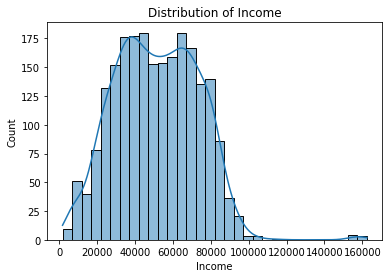

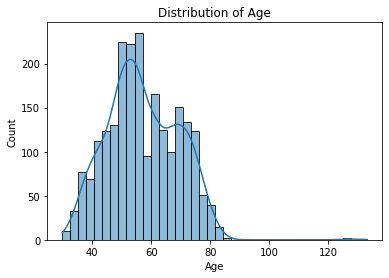

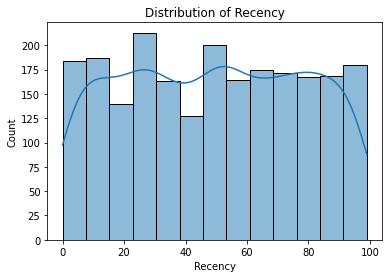

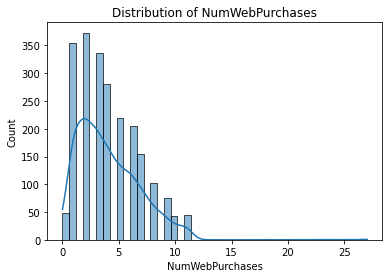

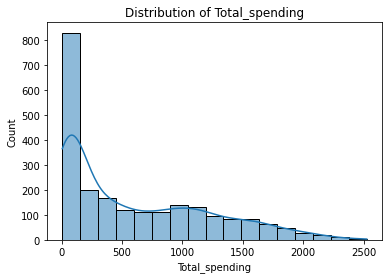

In [11]:
selected_num_cols = ['Income','Age','Recency','NumWebPurchases','Total_spending']

# Numerical Variables → Histograms
for col in selected_num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### 5.2 Categorical Variable Distributions
To explore the structure of categorical features, bar charts were created for **Education** and **Marital Status**.

These visualizations provided insights into:

- The distribution of customers across different education levels
- The frequency of each marital status category
- Potential dominance or imbalance within categorical variables

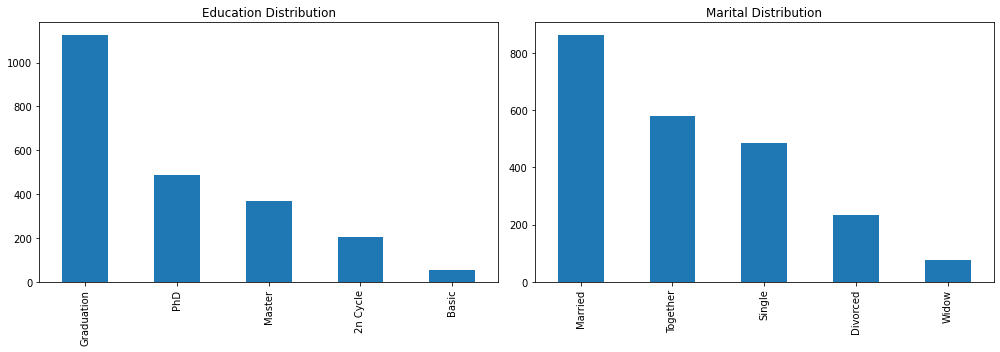

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Education Distribution
df['Education'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    title='Education Distribution')

# Marital Status Distribution
df['Marital_Status'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    title='Marital Distribution')

plt.tight_layout()
plt.show()

### 5.3 Outlier Analysis
To detect extreme or unusual values, **boxplots** were generated for all selected numerical variables.

In [37]:
# Outliers \ Boxplots
for col in selected_num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## 6. Bivariate Analysis
### 6.1 Numerical Variables vs Campaign Response
To examine relationships between customer characteristics and campaign response, **scatter plots and boxplots** were used to compare numerical variables against the **campaign response** variable.

This analysis helps in understanding whether factors such as **income, age, and purchasing behavior** have any influence on a customer’s likelihood to respond to marketing campaigns. It also supports the identification of patterns or trends that may explain differences in customer engagement levels.

In [38]:
for col in selected_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter / Strip plot
    sns.stripplot(x=df['Response'], y=df[col], jitter=True, ax=axes[0])
    axes[0].set_title(f'{col} vs Response (Scatter)')

    # Boxplot
    sns.boxplot(x='Response', y=col, data=df, ax=axes[1])
    axes[1].set_title(f'{col} vs Response (Boxplot)')

    plt.tight_layout()
    plt.show()

### 6.2 Correlation Analysis
A **correlation heatmap** was generated to examine the relationships between numerical variables and the target variable (Response). This visualization helps identify how strongly variables are related to each other and to campaign response behavior.

**Interpretation:**
- Values close to +1 indicate a **strong positive correlation**, meaning both variables tend to increase together.
- Values close to -1 indicate a **strong negative correlation**, meaning one variable increases while the other decreases.
- Values close to 0 indicate a **weak or no linear relationship** between variables.

This analysis helps in identifying the most influential variables that may impact customer response to marketing campaigns.

In [39]:
corr = df[selected_num_cols + ['Response']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 6.3 Categorical Variables vs Campaign Response
Bar plots were used to analyze **campaign response rates across Education and Marital Status categories**. In addition, **Chi-square tests of independence** were performed to statistically assess whether these categorical variables have a significant relationship with campaign response.

**Statistical Results:**
- **Education:** p-value = 0.00012226975294505314
- **Marital_Status:** p-value = 1.7384196562604576e-10

**Interpretation:**
- A p-value < 0.05 indicates a statistically significant relationship between the categorical variable and campaign response.
- A p-value ≥ 0.05 indicates no statistically significant relationship.

Based on the results, both **Education** and **Marital Status** show a statistically significant association with campaign response, suggesting that these demographic factors may influence customer engagement with marketing campaigns.

In [40]:
selected_cat_cols = ['Education','Marital_Status']

for col in selected_cat_cols:
    plt.figure()
    sns.barplot(x=col, y='Response', data=df)
    plt.title(f'Response Rate by {col}')
    plt.xticks
    plt.show()
    
for col in selected_cat_cols:
    contingency_table = pd.crosstab(df[col], df['Response'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{col}: p-value = {p}")

### 6.4 Numerical vs Categorical Relationships
To examine how customer demographics influence behavior, **boxplots** were used to compare key numerical variables across **Education** and **Marital Status** categories.

The following relationships were analyzed:

- Income by Education / Marital Status
- Total Spending by Education / Marital Status
- Recency by Education / Marital Status

This analysis provides valuable insights into how different demographic groups vary in terms of **income levels, purchasing behavior, and engagement recency**. It helps identify whether certain customer segments demonstrate distinct financial or behavioral patterns that could be useful for targeted marketing strategies.


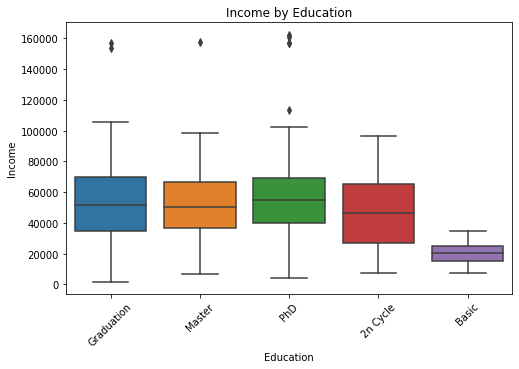

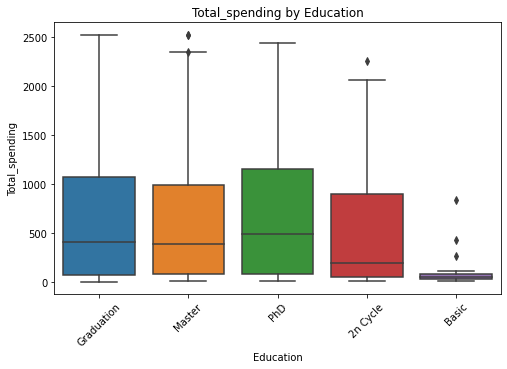

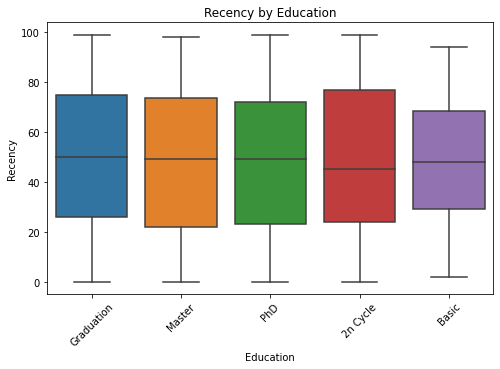

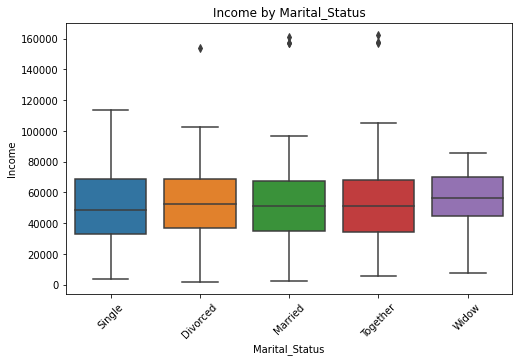

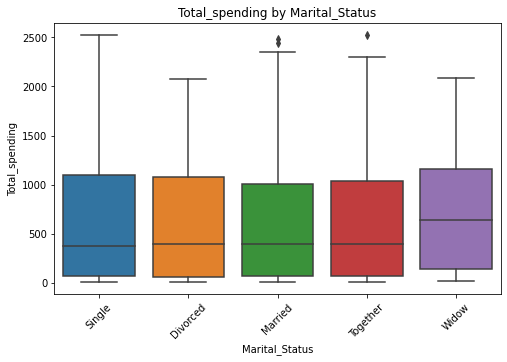

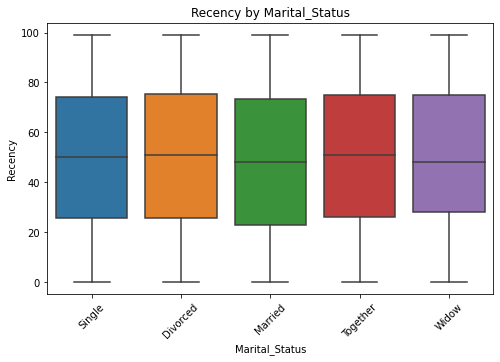

In [13]:
cat_cols = ['Education', 'Marital_Status']
num_cols = ['Income', 'Total_spending', 'Recency']

for cat in cat_cols:
    for num in num_cols:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=cat, y=num, data=df)
        plt.title(f'{num} by {cat}')
        plt.xticks(rotation=45)
        plt.show()
    

## 7. Key Observations
### Customer Demographics
Analysis of the categorical distributions indicates that the customer base is concentrated within specific education and marital status segments, highlighting the dominant demographic groups represented in the dataset. Additionally, age-related analysis suggests that the majority of customers fall within a mature adult demographic, which may influence purchasing preferences and campaign 
### Spending Behavior
Income and total spending exhibit substantial variation across customers, indicating heterogeneous purchasing power and engagement levels within the customer base. The presence of multiple outliers in income and spending variables suggests a segment of premium or high-value customers who contribute disproportionately to overall revenue and may warrant separate strategic targeting. 
### Campaign Response Trends
Bivariate analysis reveals that customers with higher income and greater total spending tend to demonstrate stronger campaign response behavior, suggesting that financially stronger and more engaged customers are more receptive to marketing efforts. Furthermore, recency patterns imply that recently active customers may respond differently to campaigns compared to less active or dormant customers, indicating the importance of customer activity timing in campaign effectiveness. 
### Statistical Relationships
Correlation analysis identifies meaningful relationships among income, spending variables, and campaign response, suggesting that purchasing behavior metrics may serve as useful predictors in future response modeling. In addition, chi-square test results confirm statistically significant relationships between campaign response and both education and marital status (p < 0.05), indicating that demographic factors play an important role in customer engagement with marketing campaigns. 
### Business Implications
The findings suggest that customer segmentation strategies based on demographic, financial, and behavioral characteristics could improve marketing campaign targeting and efficiency. Specifically, focusing on high-value - customer segments and recently active purchasers may enhance response rates and maximize campaign return on investment.




## 8. Conclusion
This exploratory data analysis provided valuable insights into customer demographics, purchasing behavior, and campaign response patterns within the marketing campaign dataset. The analysis revealed that customer income, spending behavior, recency of purchases, education level, and marital status all demonstrate meaningful relationships with marketing campaign engagement.

Higher-income and higher-spending customers generally exhibited stronger responsiveness to marketing campaigns, while statistical testing confirmed that demographic variables such as education and marital status have significant associations with campaign response. Additionally, the presence of notable outliers suggests the existence of premium customer segments that may require specialized marketing strategies.

Overall, the findings indicate that customer segmentation based on demographic and behavioral attributes can enhance marketing campaign effectiveness. These insights provide a strong foundation for **future predictive** modeling and data-driven decision-making aimed at improving customer targeting, engagement, and return on marketing investment. Building on this analysis, predictive machine learning models can be developed to forecast campaign response and identify high-potential customer segments. Variables such as income, recency, spending behavior, and demographic characteristics may serve as key predictors in classification and segmentation models, enabling the organization to further optimize targeting strategies, personalize marketing efforts, and maximize campaign performance.

